# 北京二手房价格：Python 可复现分析

## tl;dr

- 原始 CSV 含 3,000 条有效房源记录；去除 709 条完全重复记录后剩余 2,291 条。
- 在固定的 80/20 测试划分上，线性回归的测试集 R² 约为 0.670，LightGBM 约为 0.694。
- LightGBM 的测试集 MAE 约为 273 万元，低于线性回归的约 359 万元，但绝对误差仍较大。
- 结果说明面积和地区等变量具有预测信息，但现有字段不足以支持高精度估价，也不能据此作因果解释。


## Context & Methods

本 Notebook 将原先依赖 SPSS 和在线统计工具的研究重建为可检查的 Python 流程。

### Key Assumptions

- `Price` 的单位为万元，`Size` 的单位为平方米。
- `Year` 是建成年份；以数据采集年份 2018 计算房龄。
- `Year = 1900` 作为未知年份占位值处理。
- 完全重复的七字段记录从主分析中删除，以降低训练/测试泄漏风险。
- 地区使用独热编码，不把行政区编号当连续变量。


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

from src.clean_data import clean_dataframe
from src.model import fit_models

ROOT = Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "anjuke.csv"
raw = pd.read_csv(RAW_PATH, encoding="utf-8")
clean, quality = clean_dataframe(raw)
quality

{'raw_rows': 3000,
 'raw_columns': 7,
 'missing_values': {'Floor': 0,
  'Garden': 0,
  'Layout': 0,
  'Price': 0,
  'Region': 0,
  'Size': 0,
  'Year': 0},
 'extra_exact_duplicate_rows': 709,
 'clean_rows': 2291,
 'removed_exact_duplicate_rows': 709,
 'year_1900_treated_as_missing': 2,
 'district_count': 17}

## Data

In [2]:
pd.DataFrame({
    "指标": ["原始记录", "完全重复记录", "去重后记录", "区县数量"],
    "数值": [quality["raw_rows"], quality["removed_exact_duplicate_rows"],
             quality["clean_rows"], quality["district_count"]],
})

,指标,数值
0,原始记录,3000
1,完全重复记录,709
2,去重后记录,2291
3,区县数量,17


In [3]:
pd.DataFrame({
    "字段": clean.columns,
    "数据类型": clean.dtypes.astype(str).values,
})

,字段,数据类型
0,floor,int64
1,garden,str
2,layout,str
3,price_wan,float64
4,region,str
5,size_sqm,int64
6,construction_year,Int64
7,bedrooms,int64
8,living_rooms,int64
9,district,object


## Results

### 1. 描述性统计

In [4]:
clean[["price_wan", "size_sqm", "floor", "building_age_2018",
       "bedrooms", "living_rooms", "unit_price_yuan_sqm"]].describe().round(2)

,price_wan,size_sqm,floor,building_age_2018,bedrooms,living_rooms,unit_price_yuan_sqm
count,2291.00,2291.00,2291.00,2289.0,2291.00,2291.00,2291.00
mean,907.44,141.37,13.49,11.44,2.64,1.63,57282.59
std,1413.96,141.53,9.21,8.18,1.17,0.76,33296.95
min,31.00,11.00,1.00,0.0,1.00,0.00,4098.36
25%,270.00,72.00,6.00,5.0,2.00,1.00,32846.48
50%,480.00,95.00,11.00,10.0,2.00,2.00,50625.00
75%,999.00,148.00,20.00,16.0,3.00,2.00,76923.08
max,24800.00,1926.00,63.00,58.0,9.00,9.00,202156.33


### 2. 区县单位面积价格

In [5]:
district_summary = (clean.groupby("district")
    .agg(房源数=("district", "size"), 单价中位数=("unit_price_yuan_sqm", "median"))
    .sort_values("单价中位数", ascending=False))
district_summary.round(0)

,房源数,单价中位数
district,,
西城,100,111353.0
东城,66,104956.0
海淀,201,90504.0
朝阳,496,77233.0
丰台,156,60284.0
石景山,22,53512.0
门头沟,24,48510.0
大兴,135,46897.0
顺义,172,42756.0


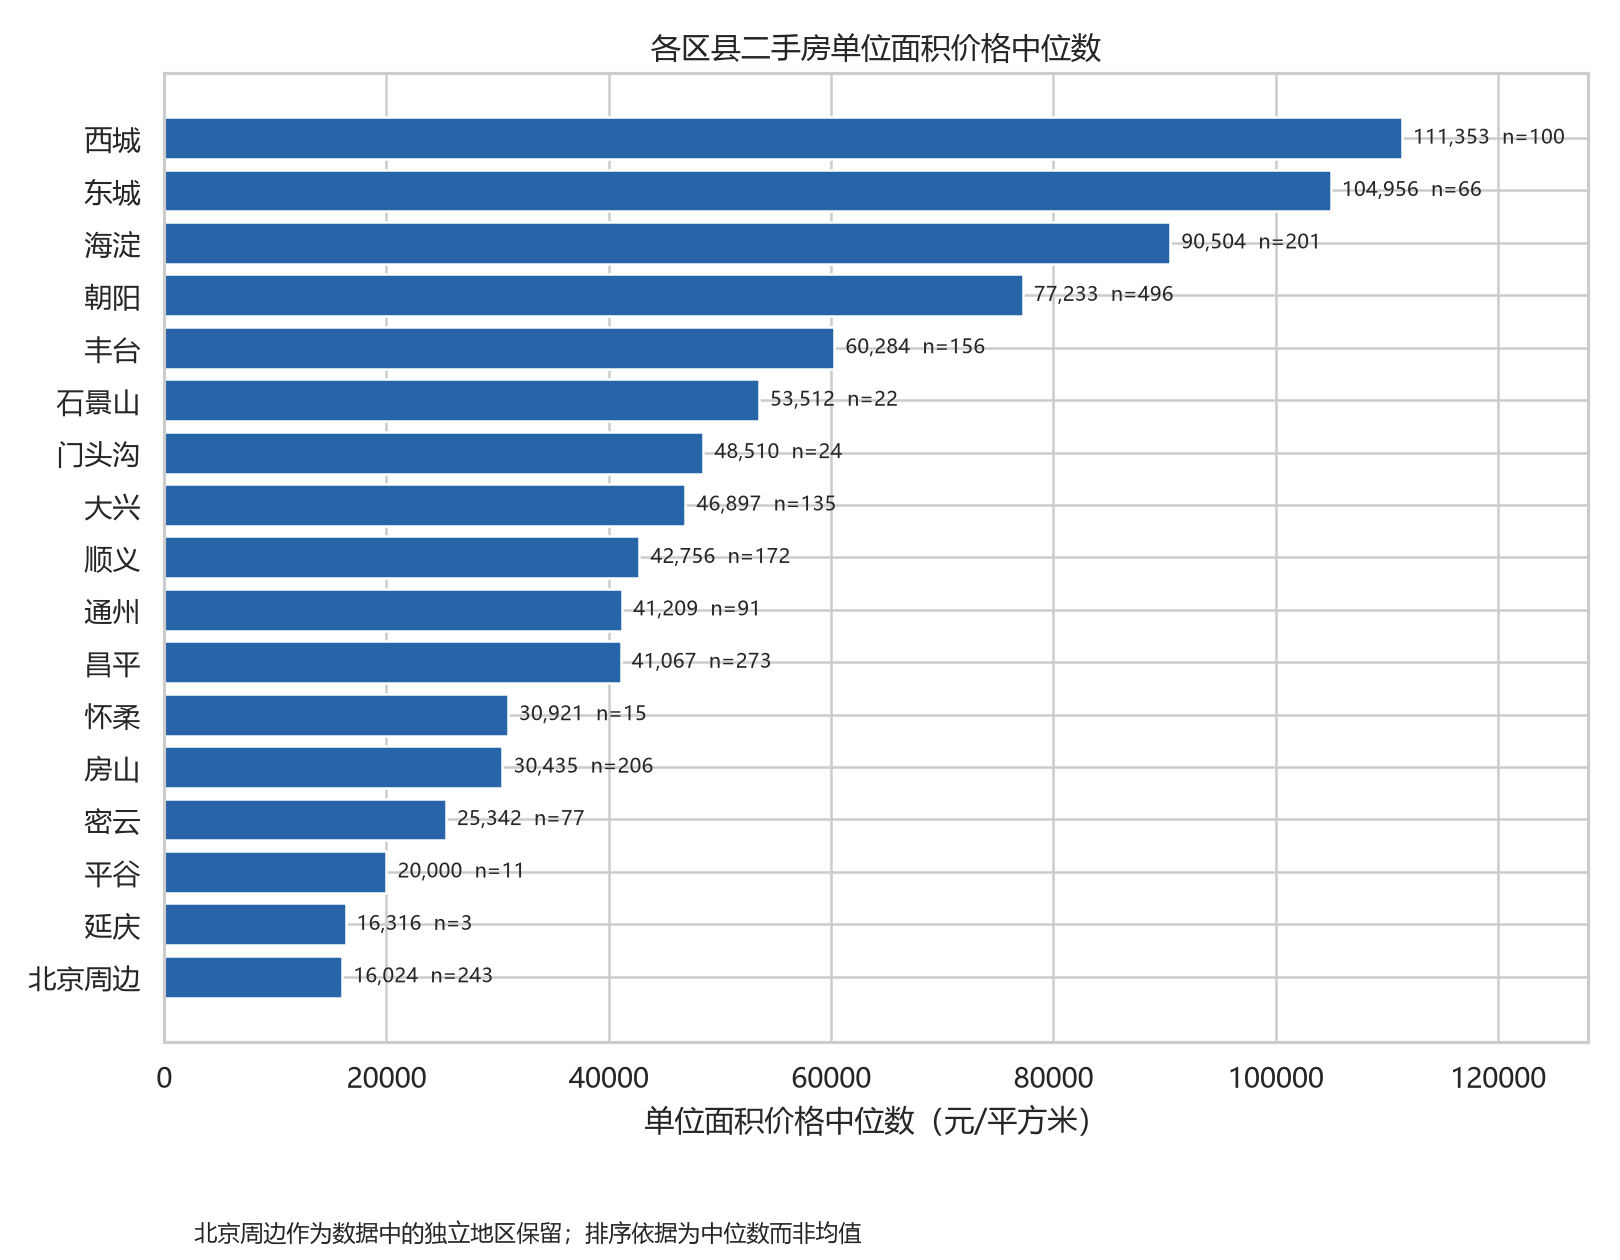

In [6]:
display(Image(filename=str(ROOT / "reports" / "figures" / "district_median_unit_price.png")))

### 3. 变量关系

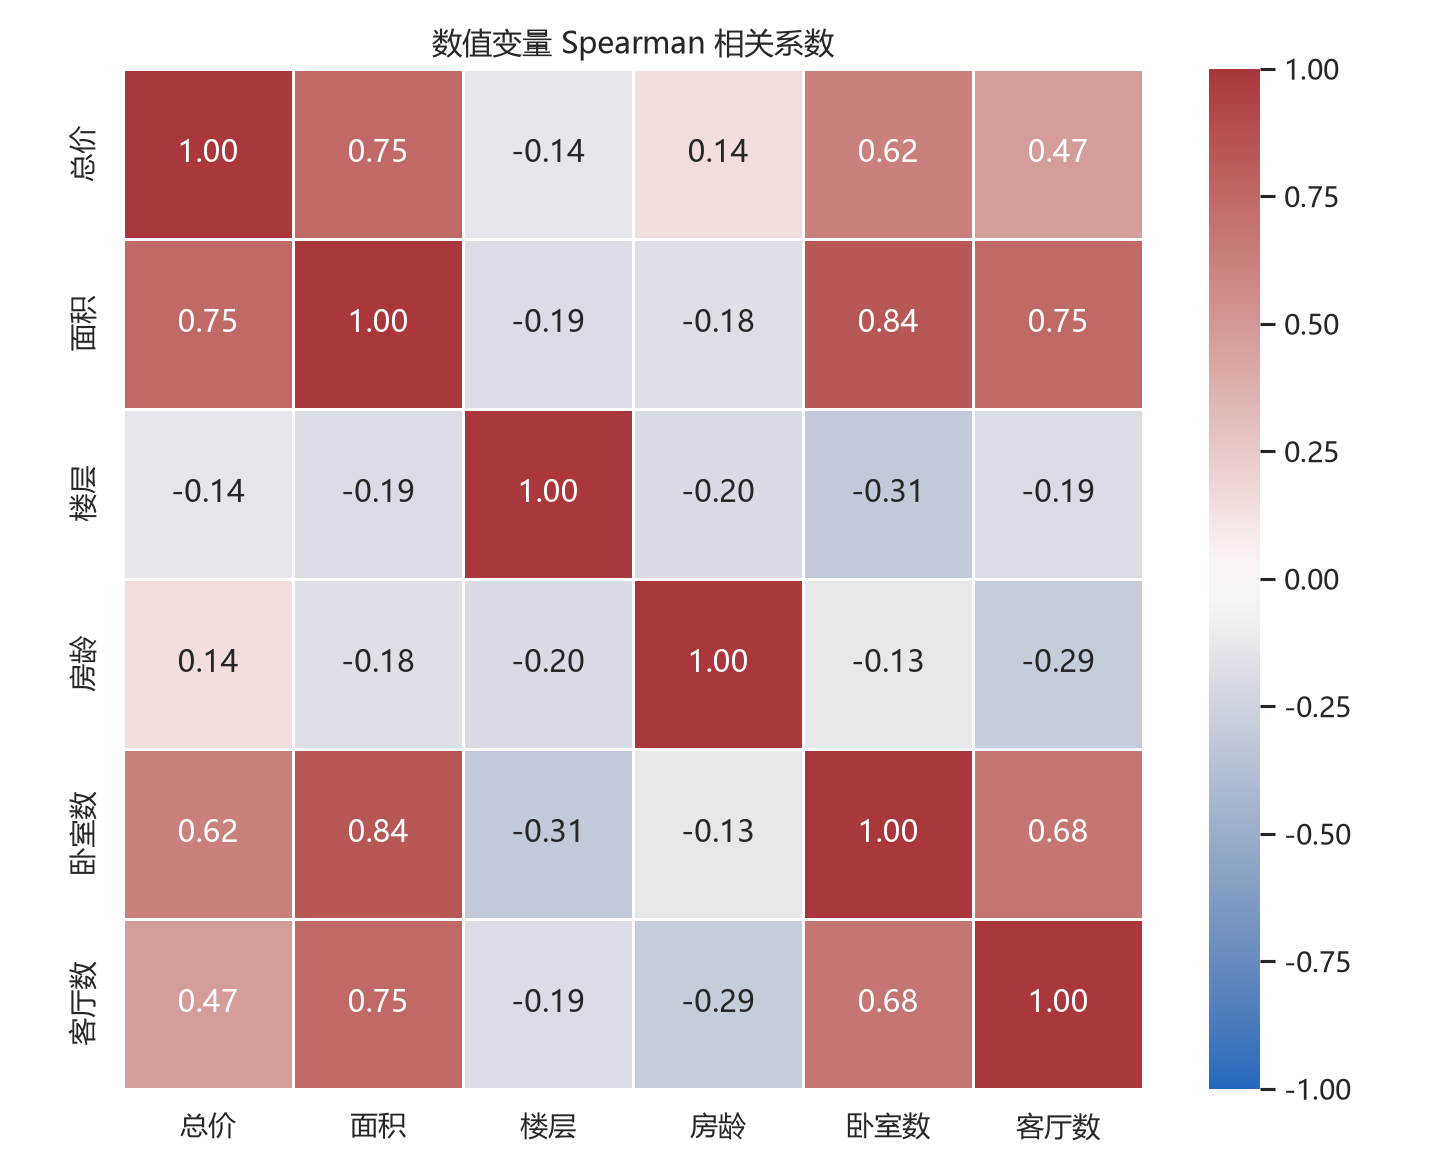

In [7]:
display(Image(filename=str(ROOT / "reports" / "figures" / "correlation_heatmap.png")))

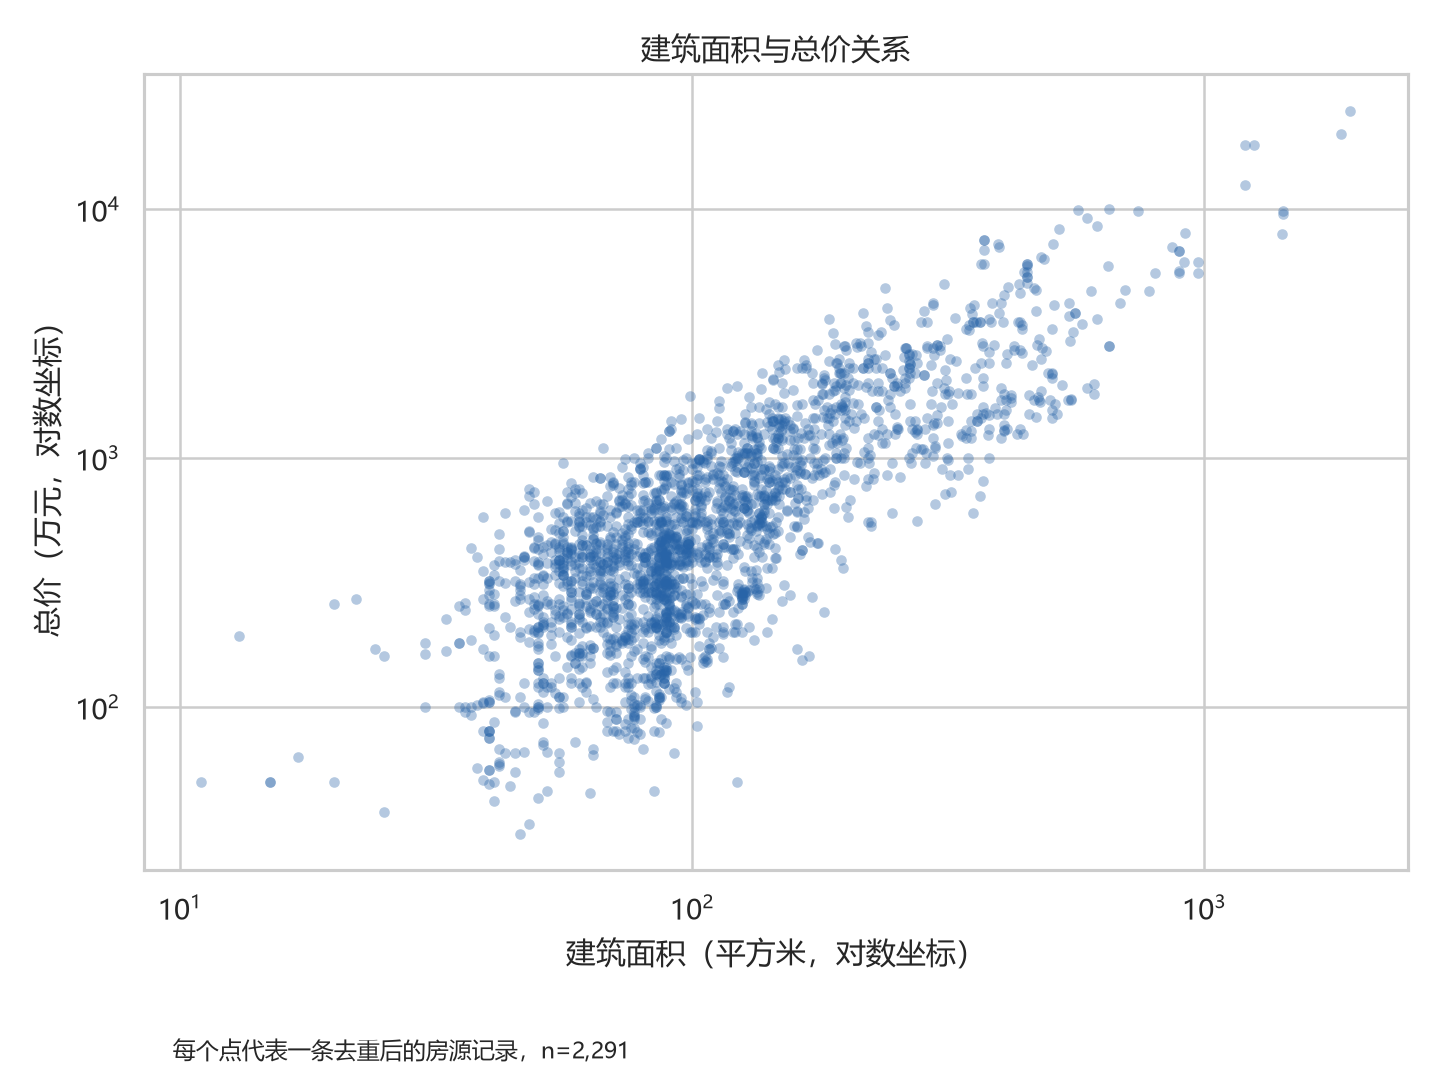

In [8]:
display(Image(filename=str(ROOT / "reports" / "figures" / "size_vs_price.png")))

### 4. 模型对比

In [9]:
model_metrics, linear_coefficients, feature_importance, predictions = fit_models(clean)
pd.DataFrame(model_metrics).loc[["mae_wan", "rmse_wan", "r2"],
                                ["linear_regression", "lightgbm"]].round(3)

,linear_regression,lightgbm
mae_wan,358.768,273.001
rmse_wan,691.095,664.900
r2,0.670,0.694


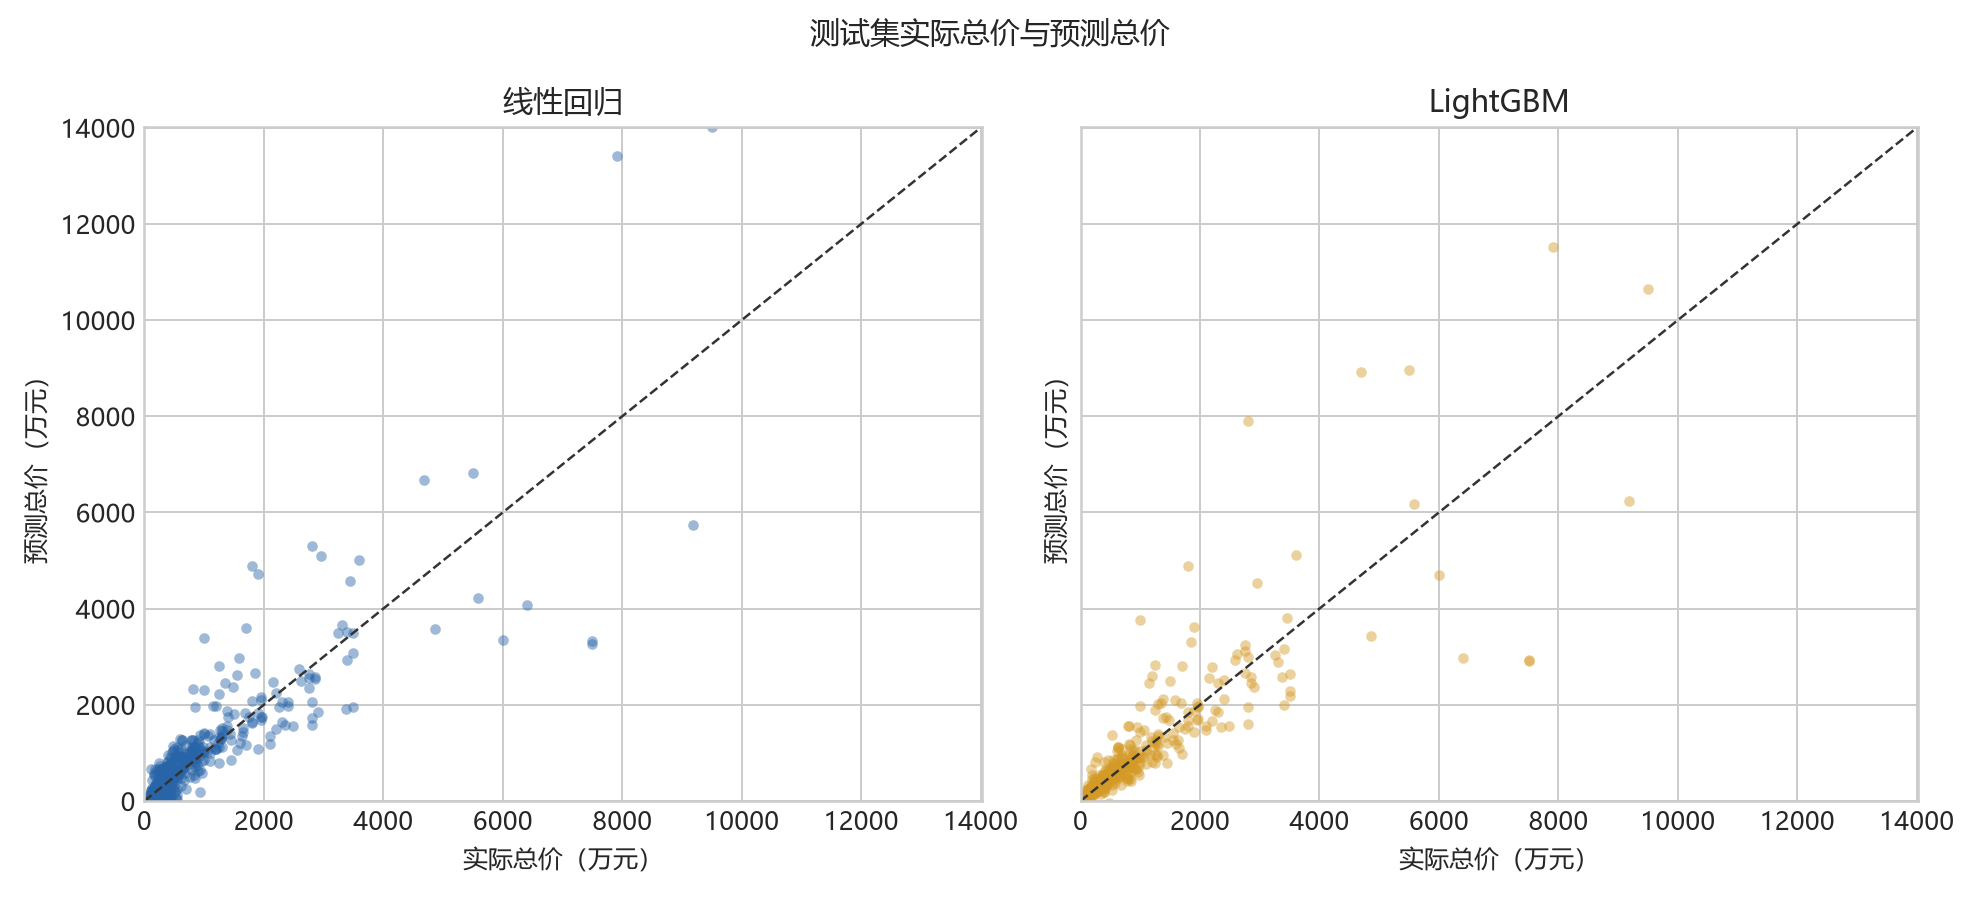

In [10]:
display(Image(filename=str(ROOT / "reports" / "figures" / "model_predictions.png")))

## Takeaways

1. 数据规模应按 3,000 条有效记录计算，Excel 中约 6,001 行来自异常换行产生的空白行。
2. 完全重复记录占比高，必须在数据划分前处理，否则容易高估泛化能力。
3. LightGBM 略优于线性回归，但测试误差仍然较大；该模型更适合作为课程项目基线，而非真实估价工具。
4. 原论文将地区数值化后直接回归的方法不稳健。本项目改用独热编码，地区系数只相对于基准地区解释。
5. 数据缺少地铁距离、装修、朝向、楼层总数和挂牌日期等重要特征，限制了预测能力。
